### *Import Library*

In [1]:
import os
import cv2
import numpy as np
import pyfeats
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, auc
)

### *Preprocessing Data*

In [2]:
# =============================================
# Preprocessing Data (Grayscale, Resize, CLAHE)
# =============================================
input_dirs = {
    'Normal': 'C:/SKRIPSI/Dataset/NORMAL',
    'Covid19': 'C:/SKRIPSI/Dataset/COVID19'
}
label_map = {'Normal': 0, 'Covid19': 1}

processed_images = []
labels = []

for label, folder in input_dirs.items():
    for fname in tqdm(os.listdir(folder), desc=f"Preprocessing {label}"):
        if fname.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img)
            processed_images.append(img)
            labels.append(label_map[label])

Preprocessing Covid19: 100%|██████████| 1000/1000 [00:49<00:00, 20.38it/s]


### *Ekstraksi Fitur*

In [3]:
# ===============================
# Ekstraksi Fitur FOS
# ===============================
fos_list = []
for img in tqdm(processed_images, desc="Ekstraksi FOS"):
    mask = np.ones_like(img)
    fos, _ = pyfeats.fos(img, mask)
    fos_list.append(fos[:10])

fos_df = pd.DataFrame(fos_list, columns=[
    'FOS_Mean', 'FOS_StdDev', 'FOS_Median', 'FOS_Mode', 'FOS_Skewness',
    'FOS_Kurtosis', 'FOS_Energy', 'FOS_Entropy', 'FOS_Min', 'FOS_Max'])
fos_df.insert(0, 'Label', labels)

# print("\n✅ Ekstraksi FOS selesai")
# print(fos_df.head())

# fos_df.to_csv("fitur_fos.csv", index=False)

Ekstraksi FOS: 100%|██████████| 2000/2000 [00:54<00:00, 36.89it/s]


### *Feature Removal*

In [4]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from scipy.stats import zscore
import joblib

# ===== Custom Transformer =====
class ZScoreMasking(BaseEstimator, TransformerMixin):
    def __init__(self, mask=None):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.mask is None:
            return X
        return X[:, self.mask]

# ===== Load Dataset =====
X = fos_df.drop(columns=['Label']).values
y = fos_df['Label'].values
feature_names = fos_df.drop(columns=['Label']).columns

print("\n📊 Jumlah fitur awal:", X.shape[1])

# ===== Hitung Statistik =====
z = np.abs(zscore(X))
mean_z = z.mean(axis=0)
var = X.var(axis=0)

print("\n🔍 Statistik per fitur:")
for i, name in enumerate(feature_names):
    print(f"  {name:20} | mean_z: {mean_z[i]:.4f} | var: {var[i]:.6f}")

# ===== Grid Threshold Setup =====
thresh_range = np.arange(0.5, 4.5, 0.25)
param_grid = []
mask_dict = {}

for t in thresh_range:
    mask = (mean_z < t) & (var > 1e-5)
    selected = np.where(mask)[0]

    if len(selected) > 1:
        corr = np.corrcoef(X[:, selected].T)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                if abs(corr[i, j]) > 0.95:
                    if mean_z[selected[i]] > mean_z[selected[j]]:
                        mask[selected[i]] = False
                    else:
                        mask[selected[j]] = False

    mask_dict[t] = mask
    print(f"📌 Threshold: {t:.2f} | Fitur tersisa: {mask.sum()}")

    param_grid.append({
        'mask__mask': [mask],
        'svc__C': [0.1, 1.0, 10.0]
    })

# ===== Build Pipeline =====
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mask', ZScoreMasking()),
    ('svc', LinearSVC(max_iter=100000, dual=False))
])

# ===== GridSearch =====
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

# ===== Ambil Kombinasi dengan Fitur < Penuh =====
results = grid.cv_results_
filtered = [
    (i, params['mask__mask'])
    for i, params in enumerate(results['params'])
    if params['mask__mask'].sum() < X.shape[1]
]

if filtered:
    # Ambil skor tertinggi di antara konfigurasi yang mengurangi fitur
    best_i, best_mask = max(
        filtered,
        key=lambda x: results['mean_test_score'][x[0]]
    )
    best_threshold = [
        t for t, m in mask_dict.items() if np.array_equal(m, best_mask)
    ][0]
    best_pipeline = grid.cv_results_['params'][best_i]
    final_model = grid.best_estimator_
else:
    # Tidak ada fitur yang terfilter → fallback
    best_mask = grid.best_params_['mask__mask']
    best_threshold = [t for t, m in mask_dict.items() if np.array_equal(m, best_mask)][0]
    final_model = grid.best_estimator_

X_filtered = X[:, best_mask]

# ===== Output Hasil =====
print("\n✅ Threshold terbaik:", best_threshold)
print("📊 Jumlah fitur sebelum masking:", X.shape[1])
print("✅ Jumlah fitur setelah masking:", X_filtered.shape[1])
print("✅ Fitur yang dipertahankan:", feature_names[best_mask].tolist())

# # ===== Simpan Model & Fitur =====
# joblib.dump(final_model, 'zscore_mask.pkl')
# print("\n💾 Pipeline terbaik disimpan sebagai: zscore_mask.pkl")



📊 Jumlah fitur awal: 10

🔍 Statistik per fitur:
  FOS_Mean             | mean_z: 0.7864 | var: 233.221111
  FOS_StdDev           | mean_z: 0.7894 | var: 1160780.867478
  FOS_Median           | mean_z: 0.7683 | var: 296.094758
  FOS_Mode             | mean_z: 0.9370 | var: 8222.991400
  FOS_Skewness         | mean_z: 0.7398 | var: 0.054290
  FOS_Kurtosis         | mean_z: 0.7215 | var: 0.176800
  FOS_Energy           | mean_z: 0.5371 | var: 0.000073
  FOS_Entropy          | mean_z: 0.7546 | var: 0.025139
  FOS_Min              | mean_z: 0.4732 | var: 21.119000
  FOS_Max              | mean_z: 0.4373 | var: 51.158778
📌 Threshold: 0.50 | Fitur tersisa: 2
📌 Threshold: 0.75 | Fitur tersisa: 5
📌 Threshold: 1.00 | Fitur tersisa: 9
📌 Threshold: 1.25 | Fitur tersisa: 9
📌 Threshold: 1.50 | Fitur tersisa: 9
📌 Threshold: 1.75 | Fitur tersisa: 9
📌 Threshold: 2.00 | Fitur tersisa: 9
📌 Threshold: 2.25 | Fitur tersisa: 9
📌 Threshold: 2.50 | Fitur tersisa: 9
📌 Threshold: 2.75 | Fitur tersisa: 9
📌 Thre

### *Normalisasi*

In [5]:
# ===============================
# ⚙️ 6. Split & Normalisasi
# ===============================
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### *Modeling*

Fitting 5 folds for each of 55 candidates, totalling 275 fits

✅ Parameter Terbaik: {'C': 100.0, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
✅ Akurasi CV Terbaik: 0.9406
✅ Akurasi pada data uji: 0.9600

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       200
     Covid19       0.98      0.94      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



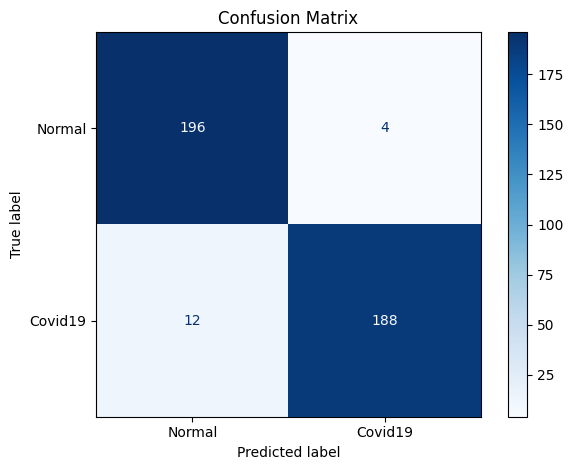

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# ------------------------
# Parameter Grid SVM
# ------------------------
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'class_weight': ['balanced']
    }
]

# ------------------------
# Grid Search CV
# ------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

# ------------------------
# Tampilkan hasil terbaik
# ------------------------
print("\n✅ Parameter Terbaik:", grid.best_params_)
print(f"✅ Akurasi CV Terbaik: {grid.best_score_:.4f}")

# ------------------------
# Evaluasi di Test Data
# ------------------------
model = grid.best_estimator_
test_acc = model.score(X_test_scaled, y_test)
print(f"✅ Akurasi pada data uji: {test_acc:.4f}")

y_pred = model.predict(X_test_scaled)

# Tambahkan label_names
label_names = list(label_map.keys())  # Fix error di sini

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# ============================
# 📉 Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### *CV Result*

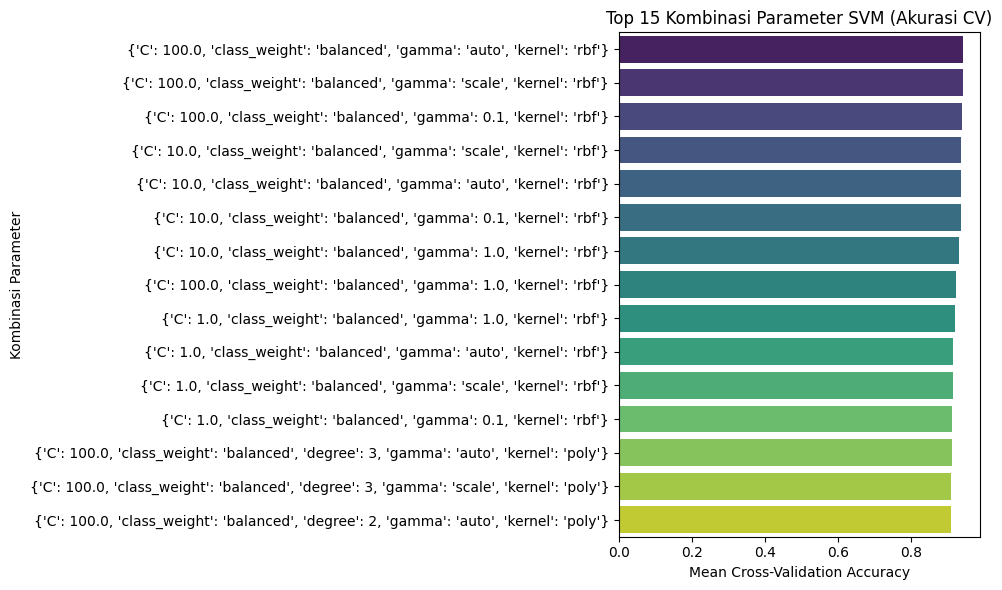

In [7]:
import seaborn as sns

# Ambil hasil grid search dalam DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# Gabungkan parameter menjadi string
cv_results["params_str"] = cv_results["params"].astype(str)

# Urutkan berdasarkan skor tertinggi
top_cv = cv_results.sort_values(by="mean_test_score", ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cv, x="mean_test_score", y="params_str", hue="params_str", dodge=False, palette="viridis", legend=False)
plt.title("Top 15 Kombinasi Parameter SVM (Akurasi CV)")
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Kombinasi Parameter")
plt.tight_layout()
plt.show()


### *Classification Report Metrics*

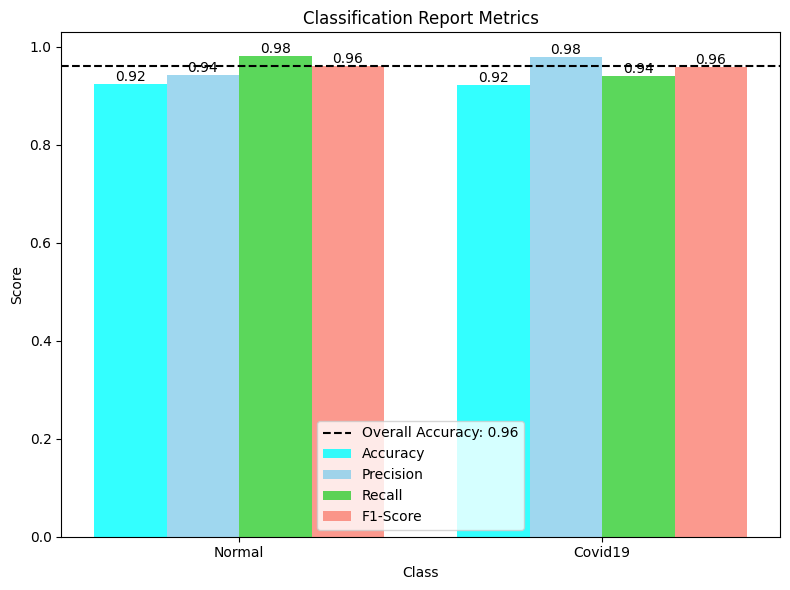


📊 Akurasi per kelas:
Kelas Normal: 0.92
Kelas Covid19: 0.92
📊 Precision: [0.94230769 0.97916667]
📊 Recall: [0.98 0.94]
📊 F1-Score: [0.96078431 0.95918367]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Pastikan y_test hanya berisi dua kelas (misalnya 0 dan 1)
unique_classes = np.unique(y_test)
if len(unique_classes) != 2:
    raise ValueError("y_test harus berisi hanya dua kelas untuk klasifikasi biner. Gunakan multiclass jika lebih dari dua kelas.")

# Hitung prediksi
y_pred = model.predict(X_test_scaled)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

# Hitung akurasi per kelas
accuracy_per_class = []
for i in range(len(unique_classes)):
    tp = cm[i, i]
    fp = sum(cm[:, i]) - tp
    fn = sum(cm[i, :]) - tp
    acc_class = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    accuracy_per_class.append(acc_class)

# Hitung precision, recall, dan f1-score untuk kedua kelas
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None, labels=unique_classes)
accuracy = model.score(X_test_scaled, y_test)

# Data untuk grafik
classes = ['Normal', 'Covid19']  # Asumsi 0=Normal, 1=Covid19
accuracy_values = accuracy_per_class
precision_values = precision
recall_values = recall
f1_score_values = f1

# Plot grafik batang
fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.2
index = np.arange(len(classes))

bars1 = ax.bar(index, accuracy_values, bar_width, label='Accuracy', color='cyan', alpha=0.8)
bars2 = ax.bar(index + bar_width, precision_values, bar_width, label='Precision', color='skyblue', alpha=0.8)
bars3 = ax.bar(index + 2 * bar_width, recall_values, bar_width, label='Recall', color='limegreen', alpha=0.8)
bars4 = ax.bar(index + 3 * bar_width, f1_score_values, bar_width, label='F1-Score', color='salmon', alpha=0.8)

# Garis dashed untuk rata-rata accuracy
ax.axhline(y=accuracy, color='black', linestyle='--', label=f'Overall Accuracy: {accuracy:.2f}')

# Label dan judul
ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Classification Report Metrics')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(classes)
ax.legend()

# Tambahkan nilai di atas batang
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
for bar in bars4:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n📊 Akurasi per kelas:")
for i, class_name in enumerate(classes):
    print(f"Kelas {class_name}: {accuracy_per_class[i]:.2f}")
print(f"📊 Precision: {precision}")
print(f"📊 Recall: {recall}")
print(f"📊 F1-Score: {f1}")

### *AUC*

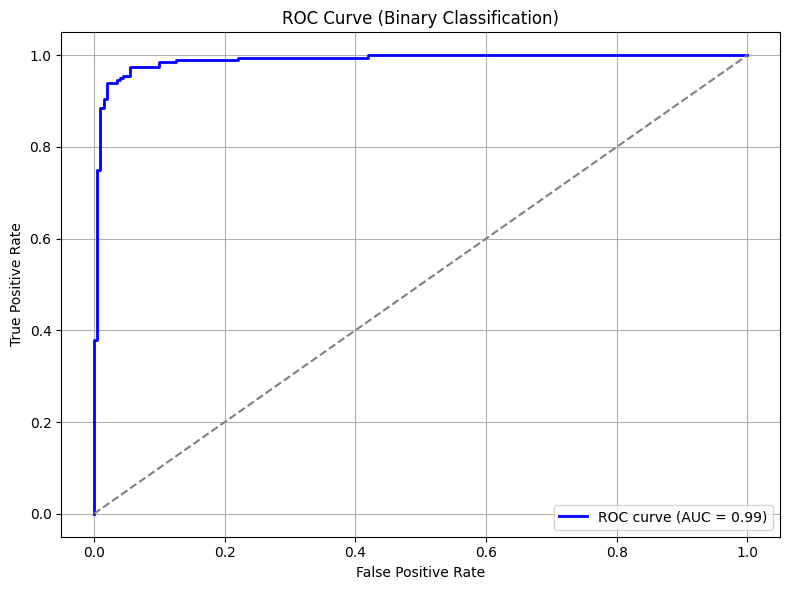

In [9]:
from sklearn.metrics import roc_curve, auc

# ROC Curve (untuk klasifikasi biner)
y_test_bin = label_binarize(y_test, classes=[0, 1]).ravel()
y_score = model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### *Save Model* 

In [10]:
# # Simpan model dan tools
joblib.dump(model, 'model_svm.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(best_mask, 'best_mask_kombinasi.pkl')
print("\nModel dan file preprocessing berhasil disimpan!")


Model dan file preprocessing berhasil disimpan!
